# TP 2 - Segmentation clients RFM

**Projet :** segmentation de clients e-commerce à partir du jeu de données réel **UCI Online Retail II**.  
**Objectif métier :** transformer un historique de transactions bruité en segments actionnables pour personnaliser les campagnes marketing, prioriser la fidélisation et limiter l'attrition.

Ce notebook suit les cinq attendus du sujet :

1. nettoyage des transactions ;
2. construction et transformation des variables RFM ;
3. choix argumenté du nombre de segments ;
4. caractérisation, nommage et recommandations ;
5. discussion critique et éthique.

## Membres du groupe

- AKAYA Eniwinéwé Henri
- ALKISSANKDEI T. Djamal
- BLAISE Mouné Tchoubou
- LARE V. Donné
- METO Kemi Gédéon
- OPEKOU-DOUDOE Christian
- TORA Dkawlma Emmanuel


## 0. Préparation

Les choix techniques ci-dessous visent la reproductibilité : chemins centralisés, graine aléatoire fixe, affichage compact et sauvegarde des livrables intermédiaires dans `outputs/`.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
DATA_PATH = Path("data/online_retail_II.xlsx")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid", palette="Set2")

## 1. Chargement des données

Le fichier UCI contient deux feuilles correspondant à deux années commerciales. On les concatène dès le départ pour éviter une segmentation partielle.

In [2]:
# Lecture des deux feuilles Excel et ajout d'une colonne de traçabilité.
excel_file = pd.ExcelFile(DATA_PATH)
frames = []

for sheet_name in excel_file.sheet_names:
    sheet = pd.read_excel(DATA_PATH, sheet_name=sheet_name)
    sheet["SourceSheet"] = sheet_name
    frames.append(sheet)

raw = pd.concat(frames, ignore_index=True)

print(f"Feuilles chargées : {excel_file.sheet_names}")
print(f"Nombre de lignes brutes : {raw.shape[0]:,}")
print(f"Nombre de colonnes brutes : {raw.shape[1]}")
raw.head()

Feuilles chargées : ['Year 2009-2010', 'Year 2010-2011']
Nombre de lignes brutes : 1,067,371
Nombre de colonnes brutes : 9


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SourceSheet
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom,Year 2009-2010
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,Year 2009-2010
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,Year 2009-2010
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom,Year 2009-2010
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom,Year 2009-2010


In [3]:
# Les noms de colonnes de la version Online Retail II diffèrent légèrement du sujet.
# On les harmonise vers un vocabulaire clair et stable pour le reste du notebook.
rename_map = {
    "Invoice": "InvoiceNo",
    "Price": "UnitPrice",
    "Customer ID": "CustomerID",
}
transactions = raw.rename(columns=rename_map).copy()

transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   InvoiceNo    1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   UnitPrice    1067371 non-null  float64       
 6   CustomerID   824364 non-null   float64       
 7   Country      1067371 non-null  object        
 8   SourceSheet  1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 73.3+ MB


In [4]:
# Premier diagnostic : valeurs manquantes, doublons et période couverte.
diagnostic_initial = pd.DataFrame({
    "type": transactions.dtypes.astype(str),
    "valeurs_manquantes": transactions.isna().sum(),
    "pct_manquant": transactions.isna().mean().mul(100),
    "valeurs_uniques": transactions.nunique(dropna=True),
})

display(diagnostic_initial)

print("Période couverte :", transactions["InvoiceDate"].min(), "->", transactions["InvoiceDate"].max())
print("Doublons exacts :", transactions.duplicated().sum())

,type,valeurs_manquantes,pct_manquant,valeurs_uniques
InvoiceNo,object,0,0.00,53628
StockCode,object,0,0.00,5305
Description,object,4382,0.41,5698
Quantity,int64,0,0.00,1057
InvoiceDate,datetime64[ns],0,0.00,47635
UnitPrice,float64,0,0.00,2807
CustomerID,float64,243007,22.77,5942
Country,object,0,0.00,43
SourceSheet,object,0,0.00,2


Période couverte : 2009-12-01 07:45:00 -> 2011-12-09 12:50:00
Doublons exacts : 12133


## 2. Partie 1 - Nettoyage des transactions

Règles retenues et justification :

- **Clients sans identifiant supprimés** : impossible de construire une récence, fréquence ou valeur monétaire par client sans `CustomerID`.
- **Annulations/retours exclus du clustering principal** : les factures commençant par `C` et les quantités négatives représentent des retours ou annulations. Elles sont conservées dans les indicateurs de contrôle, mais on segmente d'abord le comportement d'achat positif.
- **Prix et quantités non positifs exclus** : ils ne décrivent pas un achat exploitable pour le montant dépensé.
- **Doublons exacts supprimés** : ils gonflent artificiellement fréquence et montant.
- **Valeurs extrêmes plafonnées plus tard au niveau client** : les gros clients existent réellement en B2B ; les supprimer trop tôt ferait perdre un signal métier. On limite leur influence après agrégation via une winsorisation douce.

In [5]:
# Indicateurs de qualité avant filtrage : ils documentent l'impact des règles de nettoyage.
transactions["InvoiceNo"] = transactions["InvoiceNo"].astype(str)
transactions["CustomerID"] = pd.to_numeric(transactions["CustomerID"], errors="coerce")
transactions["Quantity"] = pd.to_numeric(transactions["Quantity"], errors="coerce")
transactions["UnitPrice"] = pd.to_numeric(transactions["UnitPrice"], errors="coerce")
transactions["InvoiceDate"] = pd.to_datetime(transactions["InvoiceDate"], errors="coerce")
transactions["Description"] = transactions["Description"].astype("string").str.strip()
transactions["Country"] = transactions["Country"].astype("string").str.strip()

transactions["is_cancelled_invoice"] = transactions["InvoiceNo"].str.upper().str.startswith("C")
transactions["is_return_line"] = transactions["Quantity"] < 0
transactions["LineAmount"] = transactions["Quantity"] * transactions["UnitPrice"]

cleaning_audit = pd.Series({
    "lignes_brutes": len(transactions),
    "clients_distincts_bruts": transactions["CustomerID"].nunique(dropna=True),
    "factures_annulees": transactions["is_cancelled_invoice"].sum(),
    "lignes_quantite_negative": transactions["is_return_line"].sum(),
    "customer_id_manquant": transactions["CustomerID"].isna().sum(),
    "prix_non_positif": (transactions["UnitPrice"] <= 0).sum(),
    "quantite_non_positive": (transactions["Quantity"] <= 0).sum(),
    "doublons_exacts": transactions.duplicated().sum(),
})
cleaning_audit.to_frame("valeur")

,valeur
lignes_brutes,1067371
clients_distincts_bruts,5942
factures_annulees,19494
lignes_quantite_negative,22950
customer_id_manquant,243007
prix_non_positif,6207
quantite_non_positive,22950
doublons_exacts,12133


In [6]:
# Nettoyage principal : seules les lignes d'achat positives identifiables sont gardées.
clean = (
    transactions
    .drop_duplicates()
    .loc[lambda d: d["CustomerID"].notna()]
    .loc[lambda d: d["InvoiceDate"].notna()]
    .loc[lambda d: ~d["is_cancelled_invoice"]]
    .loc[lambda d: d["Quantity"] > 0]
    .loc[lambda d: d["UnitPrice"] > 0]
    .copy()
)

clean["CustomerID"] = clean["CustomerID"].astype(int).astype(str)
clean["LineAmount"] = clean["Quantity"] * clean["UnitPrice"]

print(f"Lignes conservées : {len(clean):,} ({len(clean) / len(transactions):.1%} des lignes brutes)")
print(f"Clients conservés : {clean['CustomerID'].nunique():,}")
print(f"Chiffre d'affaires positif : £{clean['LineAmount'].sum():,.0f}")
clean.head()

Lignes conservées : 793,609 (74.4% des lignes brutes)
Clients conservés : 5,878
Chiffre d'affaires positif : £17,685,461


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,SourceSheet,is_cancelled_invoice,is_return_line,LineAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,Year 2009-2010,False,False,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,Year 2009-2010,False,False,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,Year 2009-2010,False,False,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,Year 2009-2010,False,False,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,Year 2009-2010,False,False,30.00


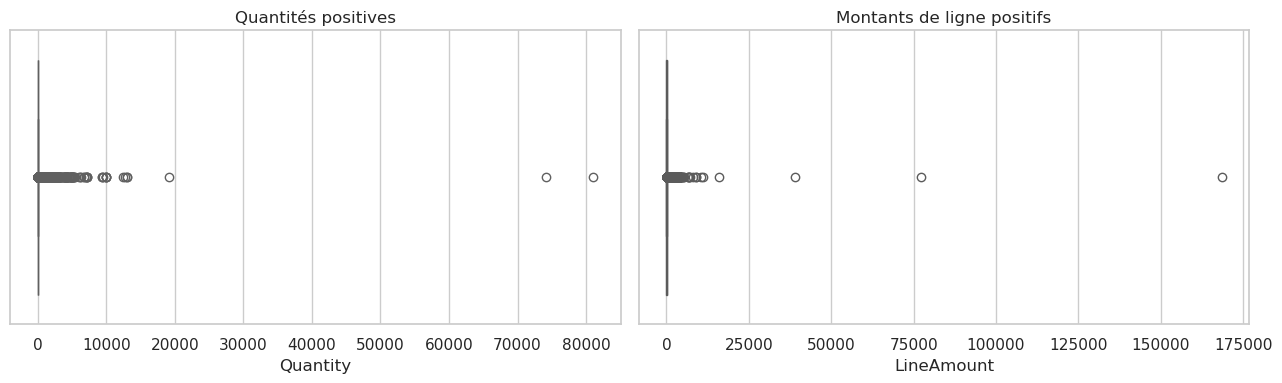

,count,mean,std,min,1%,5%,50%,95%,99%,max
Quantity,793609.00,13.45,144.69,1.00,1.00,1.00,6.00,36.00,140.00,80995.00
UnitPrice,793609.00,3.22,29.42,0.00,0.29,0.42,1.95,8.50,14.95,10953.50
LineAmount,793609.00,22.28,225.71,0.00,0.60,1.25,12.48,67.50,203.52,168469.60


In [7]:
# Contrôle des valeurs extrêmes transactionnelles.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(x=clean["Quantity"], ax=axes[0], color="#5DADE2")
axes[0].set_title("Quantités positives")
sns.boxplot(x=clean["LineAmount"], ax=axes[1], color="#58D68D")
axes[1].set_title("Montants de ligne positifs")
plt.tight_layout()
plt.show()

clean[["Quantity", "UnitPrice", "LineAmount"]].describe(percentiles=[.01, .05, .5, .95, .99]).T

## 3. Partie 2 - Construction des features RFM

La date de référence est fixée au lendemain de la dernière transaction observée. C'est plus réaliste qu'une date système, car le dataset est historique.

Définitions :

- **Recency** : nombre de jours depuis le dernier achat ; plus petit = client plus récent.
- **Frequency** : nombre de factures distinctes positives ; plus grand = client plus actif.
- **Monetary** : somme des montants positifs ; plus grand = client plus rentable.

In [8]:
analysis_date = clean["InvoiceDate"].max() + pd.Timedelta(days=1)
print("Date de référence RFM :", analysis_date.date())

rfm = (
    clean.groupby("CustomerID")
    .agg(
        Recency=("InvoiceDate", lambda s: (analysis_date - s.max()).days),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("LineAmount", "sum"),
        FirstPurchase=("InvoiceDate", "min"),
        LastPurchase=("InvoiceDate", "max"),
        CountryMode=("Country", lambda s: s.mode().iat[0] if not s.mode().empty else pd.NA),
    )
    .reset_index()
)

rfm["CustomerTenureDays"] = (analysis_date - rfm["FirstPurchase"]).dt.days
rfm["AverageBasket"] = rfm["Monetary"] / rfm["Frequency"]

print(f"Clients RFM : {len(rfm):,}")
rfm.head()

Date de référence RFM : 2011-12-10
Clients RFM : 5,878


,CustomerID,Recency,Frequency,Monetary,FirstPurchase,LastPurchase,CountryMode,CustomerTenureDays,AverageBasket
0,12346,326,12,77556.46,2009-12-14 08:34:00,2011-01-18 10:01:00,United Kingdom,726,6463.04
1,12347,2,8,5633.32,2010-10-31 14:20:00,2011-12-07 15:52:00,Iceland,404,704.16
2,12348,75,5,2019.40,2010-09-27 14:59:00,2011-09-25 13:13:00,Finland,438,403.88
3,12349,19,4,4428.69,2010-04-29 13:20:00,2011-11-21 09:51:00,Italy,589,1107.17
4,12350,310,1,334.40,2011-02-02 16:01:00,2011-02-02 16:01:00,Norway,310,334.40


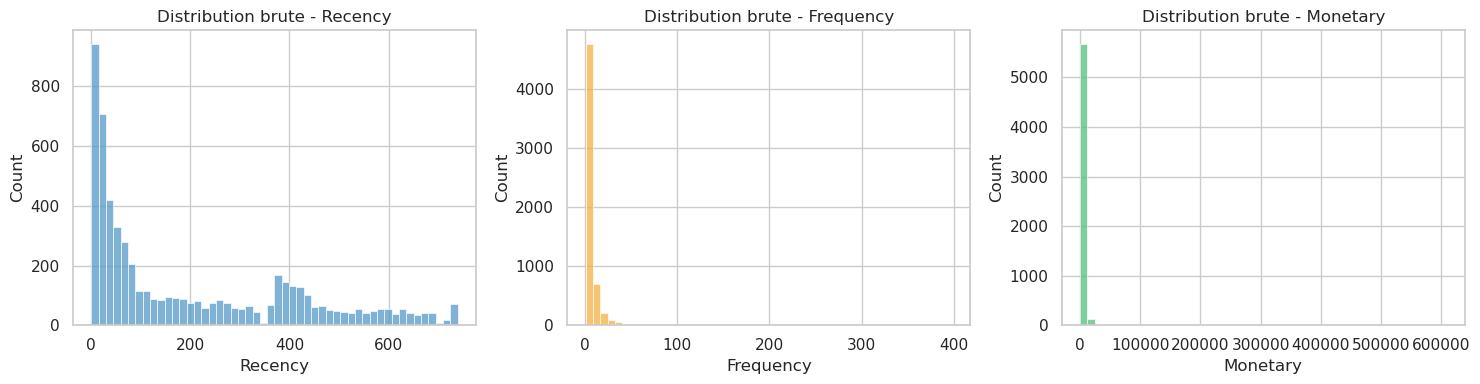

,count,mean,std,min,5%,25%,50%,75%,95%,99%,max
Recency,5878.00,201.33,209.34,1.00,4.00,26.00,96.00,380.00,625.00,726.00,739.00
Frequency,5878.00,6.29,13.01,1.00,1.00,1.00,3.00,7.00,21.00,46.00,398.00
Monetary,5878.00,3008.75,14731.92,2.95,112.53,345.12,887.39,2298.01,9504.78,29710.55,608821.65
AverageBasket,5878.00,389.99,1215.01,2.95,89.69,179.45,283.61,419.67,914.71,1994.99,84236.25


In [9]:
# Les distributions RFM sont généralement asymétriques : quelques clients B2B concentrent une forte valeur.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes, ["Recency", "Frequency", "Monetary"], ["#5499C7", "#F5B041", "#52BE80"]):
    sns.histplot(rfm[col], bins=50, ax=ax, color=color)
    ax.set_title(f"Distribution brute - {col}")
plt.tight_layout()
plt.show()

rfm[["Recency", "Frequency", "Monetary", "AverageBasket"]].describe(percentiles=[.05, .25, .5, .75, .95, .99]).T

In [10]:
# Winsorisation douce au 99e percentile : on limite l'influence des valeurs extrêmes
# sans supprimer les gros clients, qui sont importants commercialement.
rfm_model = rfm[["CustomerID", "Recency", "Frequency", "Monetary"]].copy()
for col in ["Recency", "Frequency", "Monetary"]:
    upper = rfm_model[col].quantile(0.99)
    rfm_model[f"{col}_Capped"] = rfm_model[col].clip(upper=upper)

# log1p réduit l'asymétrie et rend les distances euclidiennes plus comparables.
for col in ["Recency", "Frequency", "Monetary"]:
    rfm_model[f"log_{col}"] = np.log1p(rfm_model[f"{col}_Capped"])

feature_cols = ["log_Recency", "log_Frequency", "log_Monetary"]
scaler = StandardScaler()
X = scaler.fit_transform(rfm_model[feature_cols])

rfm_model[feature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
log_Recency,5878.00,4.45,1.56,0.69,3.30,4.57,5.94,6.59
log_Frequency,5878.00,1.54,0.79,0.69,0.69,1.39,2.08,3.85
log_Monetary,5878.00,6.82,1.36,1.37,5.85,6.79,7.74,10.30


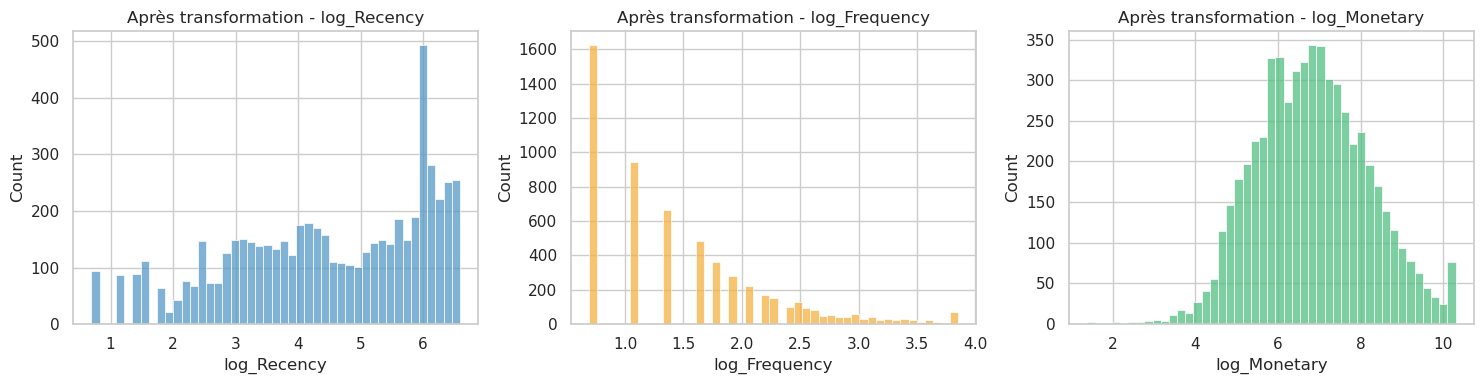

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes, feature_cols, ["#5499C7", "#F5B041", "#52BE80"]):
    sns.histplot(rfm_model[col], bins=45, ax=ax, color=color)
    ax.set_title(f"Après transformation - {col}")
plt.tight_layout()
plt.show()

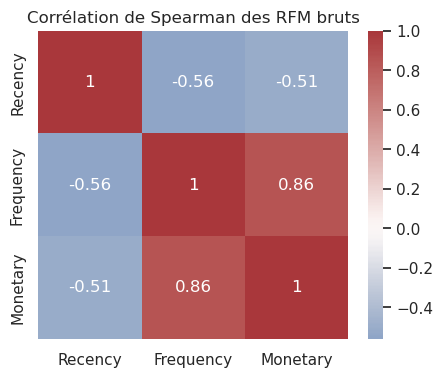

In [12]:
# Vérification de la corrélation : utile pour discuter la redondance Fréquence/Montant.
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(rfm[["Recency", "Frequency", "Monetary"]].corr(method="spearman"), annot=True, cmap="vlag", center=0, ax=ax)
ax.set_title("Corrélation de Spearman des RFM bruts")
plt.show()

## 4. Partie 3 - Clustering et choix de k

On utilise **K-means** sur les variables `log1p + standardisées` :

- K-means compare les clients par distances ; les RFM bruts mélangeraient des unités et amplitudes très différentes.
- La transformation logarithmique réduit l'effet des très gros montants/fréquences.
- La standardisation donne un poids comparable à récence, fréquence et montant.

Le choix de `k` ne repose pas uniquement sur un score. On compare :

- **inertie** : baisse de compacité intra-cluster ;
- **silhouette** : séparation moyenne ;
- **stabilité** : accord moyen entre plusieurs initialisations ;
- **cohérence métier** : segments suffisamment nombreux pour être actionnables, mais pas trop fragmentés.

In [13]:
def stability_for_k(X, k, seeds=range(10)):
    # Mesure simple de stabilité : ARI moyen entre plusieurs initialisations K-means.
    labels = []
    for seed in seeds:
        model = KMeans(n_clusters=k, random_state=seed, n_init=20)
        labels.append(model.fit_predict(X))

    scores = []
    for i in range(len(labels)):
        for j in range(i + 1, len(labels)):
            scores.append(adjusted_rand_score(labels[i], labels[j]))
    return float(np.mean(scores))

k_values = range(2, 9)
evaluation_rows = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=50)
    labels = model.fit_predict(X)
    counts = pd.Series(labels).value_counts(normalize=True)
    evaluation_rows.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(X, labels),
        "stability_ari": stability_for_k(X, k),
        "smallest_segment_pct": counts.min() * 100,
    })

k_eval = pd.DataFrame(evaluation_rows)
k_eval

,k,inertia,silhouette,stability_ari,smallest_segment_pct
0,2,8443.19,0.44,1.00,39.88
1,3,6204.19,0.35,1.00,21.08
2,4,4759.29,0.37,1.00,20.81
3,5,3984.88,0.34,0.96,9.99
4,6,3428.18,0.34,0.98,9.53
5,7,3066.55,0.30,0.94,7.21
6,8,2772.89,0.30,0.99,6.77


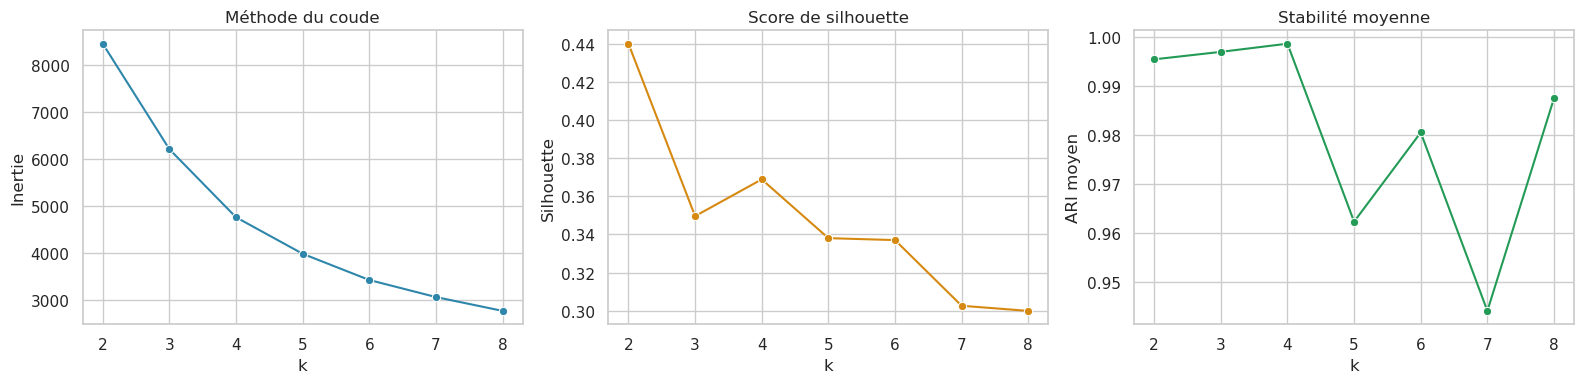

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.lineplot(data=k_eval, x="k", y="inertia", marker="o", ax=axes[0], color="#2E86AB")
axes[0].set_title("Méthode du coude")
axes[0].set_ylabel("Inertie")

sns.lineplot(data=k_eval, x="k", y="silhouette", marker="o", ax=axes[1], color="#D68910")
axes[1].set_title("Score de silhouette")
axes[1].set_ylabel("Silhouette")

sns.lineplot(data=k_eval, x="k", y="stability_ari", marker="o", ax=axes[2], color="#239B56")
axes[2].set_title("Stabilité moyenne")
axes[2].set_ylabel("ARI moyen")

for ax in axes:
    ax.set_xticks(list(k_values))

plt.tight_layout()
plt.show()

In [15]:
# Choix final : 5 segments.
# Justification métier : 5 groupes permettent de distinguer clients premium, clients actifs rentables,
# nouveaux occasionnels, clients à risque et clients dormants/faible valeur.
# Les métriques précédentes servent à vérifier que ce choix reste stable et raisonnable.
FINAL_K = 5

kmeans = KMeans(n_clusters=FINAL_K, random_state=RANDOM_STATE, n_init=100)
rfm_model["Cluster"] = kmeans.fit_predict(X)

rfm_clustered = rfm.merge(rfm_model[["CustomerID", "Cluster"]], on="CustomerID", how="left")
rfm_clustered["Cluster"] = rfm_clustered["Cluster"].astype(int)

rfm_clustered["Cluster"].value_counts().sort_index().to_frame("effectif")

,effectif
Cluster,
0,587
1,1580
2,1250
3,1126
4,1335


## 5. Partie 4 - Caractérisation et nommage des segments

Les segments sont nommés à partir du profil RFM moyen : récence faible = achat récent, fréquence élevée = engagement, montant élevé = valeur économique.

In [16]:
cluster_profile = (
    rfm_clustered.groupby("Cluster")
    .agg(
        Effectif=("CustomerID", "nunique"),
        Recency_mean=("Recency", "mean"),
        Frequency_mean=("Frequency", "mean"),
        Monetary_mean=("Monetary", "mean"),
        Monetary_total=("Monetary", "sum"),
        AverageBasket_mean=("AverageBasket", "mean"),
        Tenure_mean=("CustomerTenureDays", "mean"),
    )
    .reset_index()
)
cluster_profile["Pct_clients"] = cluster_profile["Effectif"] / cluster_profile["Effectif"].sum() * 100
cluster_profile["Pct_CA"] = cluster_profile["Monetary_total"] / cluster_profile["Monetary_total"].sum() * 100

# Scores métier : plus la récence est basse, meilleur est le score.
profile_ranked = cluster_profile.copy()
profile_ranked["r_score"] = profile_ranked["Recency_mean"].rank(ascending=False)
profile_ranked["f_score"] = profile_ranked["Frequency_mean"].rank(ascending=True)
profile_ranked["m_score"] = profile_ranked["Monetary_mean"].rank(ascending=True)
profile_ranked["rfm_score"] = profile_ranked[["r_score", "f_score", "m_score"]].sum(axis=1)

profile_ranked.sort_values("rfm_score", ascending=False)

,Cluster,Effectif,Recency_mean,Frequency_mean,Monetary_mean,Monetary_total,AverageBasket_mean,Tenure_mean,Pct_clients,Pct_CA,r_score,f_score,m_score,rfm_score
0,0,587,18.00,28.56,17829.92,10466163.38,690.67,654.02,9.99,59.18,5.00,5.00,5.00,15.00
2,2,1250,58.36,8.56,3412.10,4265129.19,445.93,558.36,21.27,24.12,3.00,4.00,4.00,11.00
3,3,1126,32.30,2.50,683.75,769902.44,308.48,244.58,19.16,4.35,4.00,2.00,2.00,8.00
4,4,1335,303.15,3.56,1337.73,1785866.10,474.98,545.26,22.71,10.10,2.00,3.00,3.00,8.00
1,1,1580,416.98,1.23,252.15,398399.52,220.31,446.32,26.88,2.25,1.00,1.00,1.00,3.00


In [17]:
def assign_segment_names(profile):
    # Associe des noms métier uniques aux clusters selon leur position RFM relative.
    # Le score RFM sert de base, puis les arbitrages tiennent compte de la récence
    # et de la valeur historique pour éviter des noms trompeurs.
    p = profile.copy()
    p["segment_name"] = None

    champions_cluster = p.sort_values("rfm_score", ascending=False).iloc[0]["Cluster"]
    p.loc[p["Cluster"] == champions_cluster, "segment_name"] = "Champions"

    sleeping_cluster = p.sort_values("rfm_score", ascending=True).iloc[0]["Cluster"]
    p.loc[p["Cluster"] == sleeping_cluster, "segment_name"] = "Endormis faible valeur"

    remaining = p[p["segment_name"].isna()].copy()
    risk_cluster = remaining.sort_values(["Recency_mean", "Monetary_mean"], ascending=[False, False]).iloc[0]["Cluster"]
    p.loc[p["Cluster"] == risk_cluster, "segment_name"] = "À risque"

    remaining = p[p["segment_name"].isna()].copy()
    active_cluster = remaining.sort_values("Monetary_mean", ascending=False).iloc[0]["Cluster"]
    p.loc[p["Cluster"] == active_cluster, "segment_name"] = "Actifs rentables"

    p.loc[p["segment_name"].isna(), "segment_name"] = "Nouveaux occasionnels"
    return p[["Cluster", "segment_name"]]

segment_names = assign_segment_names(profile_ranked)
rfm_clustered = rfm_clustered.merge(segment_names, on="Cluster", how="left")

segment_names.sort_values("Cluster")

,Cluster,segment_name
0,0,Champions
1,1,Endormis faible valeur
2,2,Actifs rentables
3,3,Nouveaux occasionnels
4,4,À risque


In [18]:
# Ajout du segment au niveau transaction pour caractériser pays et produits.
clean_segmented = clean.merge(rfm_clustered[["CustomerID", "segment_name"]], on="CustomerID", how="left")

def top_values_by_revenue(data, group_col, value_col, n=3):
    revenue = (
        data.groupby([group_col, value_col], dropna=True)["LineAmount"]
        .sum()
        .reset_index()
        .sort_values([group_col, "LineAmount"], ascending=[True, False])
    )
    top = (
        revenue.groupby(group_col)
        .head(n)
        .groupby(group_col)[value_col]
        .apply(lambda s: ", ".join(s.astype(str)))
    )
    return top

top_countries = top_values_by_revenue(clean_segmented, "segment_name", "Country", n=3)
top_products = top_values_by_revenue(clean_segmented, "segment_name", "Description", n=3)

segment_summary = (
    rfm_clustered.groupby("segment_name")
    .agg(
        Effectif=("CustomerID", "nunique"),
        Recence_moy=("Recency", "mean"),
        Frequence_moy=("Frequency", "mean"),
        Montant_moy=("Monetary", "mean"),
        CA_total=("Monetary", "sum"),
        Panier_moy=("AverageBasket", "mean"),
    )
)
segment_summary["Pct_clients"] = segment_summary["Effectif"] / segment_summary["Effectif"].sum() * 100
segment_summary["Pct_CA"] = segment_summary["CA_total"] / segment_summary["CA_total"].sum() * 100
segment_summary["Top pays"] = segment_summary.index.map(top_countries)
segment_summary["Top produits"] = segment_summary.index.map(top_products)

segment_summary = (
    segment_summary
    .reset_index()
    .rename(columns={"segment_name": "Segment"})
    .sort_values("Pct_CA", ascending=False)
)

ordered_cols = ["Segment", "Effectif", "Pct_clients", "Pct_CA", "Recence_moy", "Frequence_moy", "Montant_moy", "Panier_moy", "Top pays", "Top produits"]
segment_summary[ordered_cols]

,Segment,Effectif,Pct_clients,Pct_CA,Recence_moy,Frequence_moy,Montant_moy,Panier_moy,Top pays,Top produits
1,Champions,587,9.99,59.18,18.00,28.56,17829.92,690.67,"United Kingdom, EIRE, Netherlands","REGENCY CAKESTAND 3 TIER, PAPER CRAFT , LITTLE..."
0,Actifs rentables,1250,21.27,24.12,58.36,8.56,3412.10,445.93,"United Kingdom, Germany, France","MEDIUM CERAMIC TOP STORAGE JAR, WHITE HANGING ..."
4,À risque,1335,22.71,10.10,303.15,3.56,1337.73,474.98,"United Kingdom, Germany, Denmark","Manual, WHITE HANGING HEART T-LIGHT HOLDER, RE..."
3,Nouveaux occasionnels,1126,19.16,4.35,32.30,2.50,683.75,308.48,"United Kingdom, Germany, France","POSTAGE, REGENCY CAKESTAND 3 TIER, WHITE HANGI..."
2,Endormis faible valeur,1580,26.88,2.25,416.98,1.23,252.15,220.31,"United Kingdom, France, Germany","WHITE HANGING HEART T-LIGHT HOLDER, REGENCY CA..."


In [19]:
recommendations = {
    "Champions": "Programme VIP, accès anticipé, cadeaux relationnels et demande d'avis/ambassadeurs. Objectif : protéger la valeur et encourager le bouche-à-oreille.",
    "Actifs rentables": "Bundles, seuils de livraison gratuite et recommandations de produits complémentaires. Objectif : consolider une forte valeur déjà récente.",
    "Nouveaux occasionnels": "Coupon de deuxième achat, onboarding court et sélection de best-sellers. Objectif : transformer l'achat récent en habitude.",
    "À risque": "Campagne de réactivation personnalisée avec offre limitée dans le temps. Objectif : récupérer des clients ayant un historique utile mais une récence défavorable.",
    "Endormis faible valeur": "Relance automatisée peu coûteuse, puis réduction de la pression marketing si absence de réponse. Objectif : maîtriser le coût commercial.",
}

recommendations_table = segment_summary[["Segment", "Effectif", "Pct_CA"]].copy()
recommendations_table["Recommandation marketing"] = recommendations_table["Segment"].map(recommendations)
recommendations_table

,Segment,Effectif,Pct_CA,Recommandation marketing
1,Champions,587,59.18,"Programme VIP, accès anticipé, cadeaux relatio..."
0,Actifs rentables,1250,24.12,"Bundles, seuils de livraison gratuite et recom..."
4,À risque,1335,10.10,Campagne de réactivation personnalisée avec of...
3,Nouveaux occasionnels,1126,4.35,"Coupon de deuxième achat, onboarding court et ..."
2,Endormis faible valeur,1580,2.25,"Relance automatisée peu coûteuse, puis réducti..."


### Tableau image des recommandations

Le tableau ci-dessous est généré automatiquement à partir du fichier `outputs/recommandations_segments.csv`. Il peut être intégré directement dans le rapport ou utilisé pendant la présentation orale.


Image générée : outputs/tableau_recommandations.png


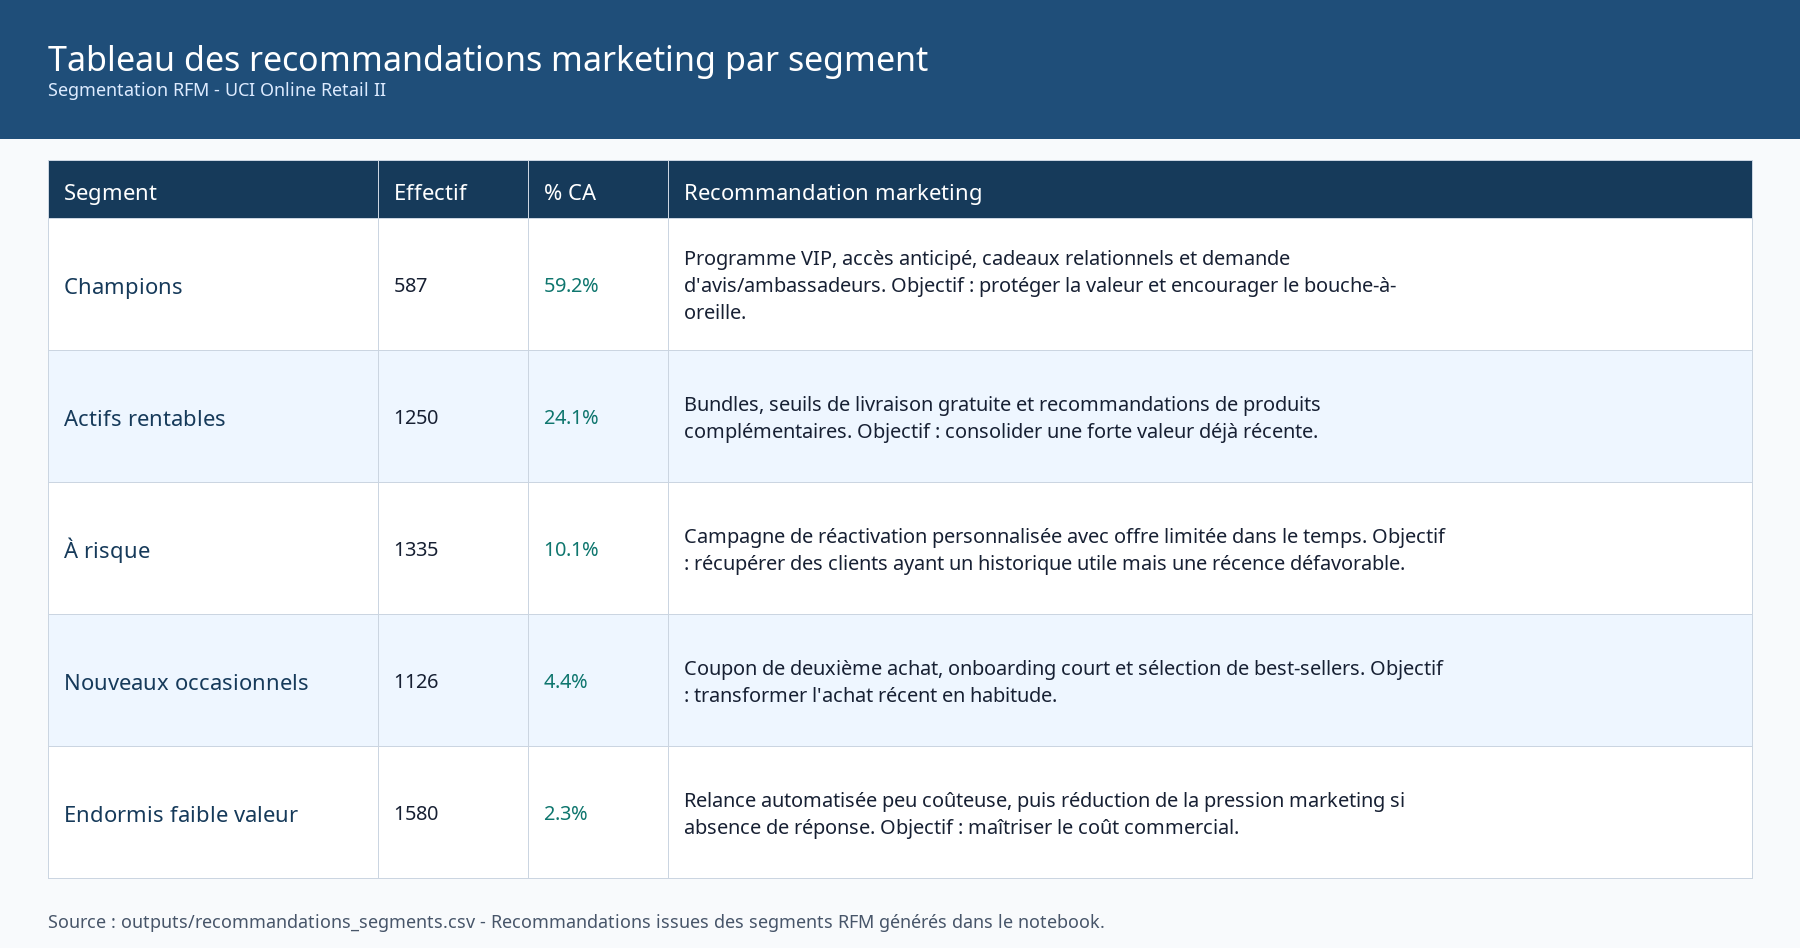

In [20]:
# Génération d'un tableau image pour la présentation.
# L'image est pratique pour intégrer les recommandations dans un support PowerPoint,
# un rapport PDF ou une démonstration orale.
import csv
import subprocess
import textwrap
from PIL import Image, ImageDraw, ImageFont
from IPython.display import Image as DisplayImage, display

recommendation_csv = OUTPUT_DIR / "recommandations_segments.csv"
recommendation_image = OUTPUT_DIR / "tableau_recommandations.png"

with recommendation_csv.open(newline="", encoding="utf-8") as f:
    rows = list(csv.DictReader(f))


def find_font_path():
    """Retourne une police système compatible avec les accents, si disponible."""
    try:
        result = subprocess.check_output(["fc-match", "-v", "NotoSans-Regular.ttf"], text=True)
        for line in result.splitlines():
            line = line.strip()
            if line.startswith("file:"):
                return line.split('"')[1]
    except Exception:
        return None
    return None

font_file = find_font_path()
font_title = ImageFont.truetype(font_file, 34) if font_file else ImageFont.load_default()
font_header = ImageFont.truetype(font_file, 22) if font_file else ImageFont.load_default()
font_body = ImageFont.truetype(font_file, 20) if font_file else ImageFont.load_default()
font_small = ImageFont.truetype(font_file, 18) if font_file else ImageFont.load_default()

width = 1800
margin = 48
title_height = 90
header_height = 58
row_height = 132
footer_height = 44
height = margin * 2 + title_height + header_height + row_height * len(rows) + footer_height

image = Image.new("RGB", (width, height), "#F8FAFC")
draw = ImageDraw.Draw(image)

blue = "#1F4E79"
blue_dark = "#163A5A"
grid = "#CBD5E1"
text = "#172033"
muted = "#475569"
white = "#FFFFFF"
row_alt = "#EEF6FF"
green = "#0F766E"

draw.rectangle([0, 0, width, margin + title_height], fill=blue)
draw.text((margin, 34), "Tableau des recommandations marketing par segment", fill=white, font=font_title)
draw.text((margin, 76), "Segmentation RFM - UCI Online Retail II", fill="#DDEBFF", font=font_small)

x0 = margin
y = margin + title_height + 22
column_widths = [330, 150, 140, width - 2 * margin - 330 - 150 - 140]
headers = ["Segment", "Effectif", "% CA", "Recommandation marketing"]

x = x0
for header, col_width in zip(headers, column_widths):
    draw.rectangle([x, y, x + col_width, y + header_height], fill=blue_dark, outline=grid)
    draw.text((x + 16, y + 16), header, fill=white, font=font_header)
    x += col_width

y += header_height
for index, row in enumerate(rows):
    fill = white if index % 2 == 0 else row_alt
    draw.rectangle([x0, y, width - margin, y + row_height], fill=fill, outline=grid)

    pct_ca = f"{float(row['Pct_CA']):.1f}%"
    values = [row["Segment"], row["Effectif"], pct_ca, row["Recommandation marketing"]]
    wraps = [22, 9, 8, 82]
    fonts = [font_header, font_body, font_body, font_body]
    colors = [blue_dark, text, green, text]

    x = x0
    for value, col_width, wrap, font, color in zip(values, column_widths, wraps, fonts, colors):
        draw.rectangle([x, y, x + col_width, y + row_height], outline=grid)
        lines = textwrap.wrap(str(value), width=wrap, break_long_words=False)
        line_height = 27
        start_y = y + max(14, (row_height - line_height * len(lines)) // 2)
        for line_index, line in enumerate(lines[:4]):
            draw.text((x + 16, start_y + line_index * line_height), line, fill=color, font=font)
        x += col_width
    y += row_height

footer = "Source : outputs/recommandations_segments.csv - Recommandations issues des segments RFM générés dans le notebook."
draw.text((margin, height - margin + 8), footer, fill=muted, font=font_small)

image.save(recommendation_image, quality=95)
print(f"Image générée : {recommendation_image}")
display(DisplayImage(filename=str(recommendation_image)))


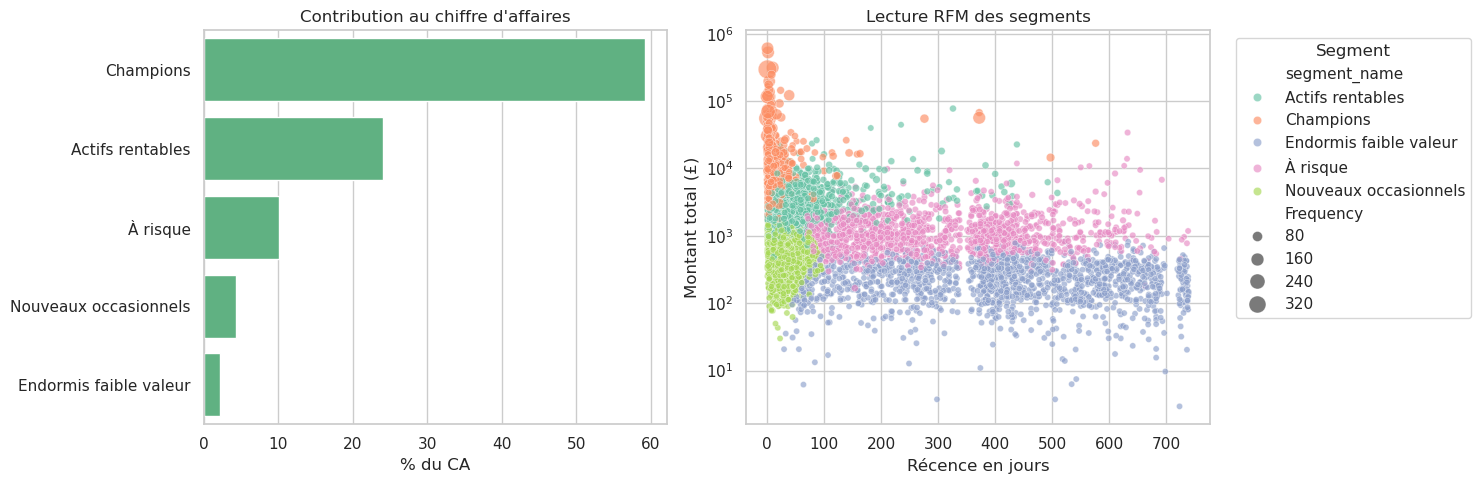

In [21]:
# Visualisations finales pour le rapport.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=segment_summary, y="Segment", x="Pct_CA", ax=axes[0], color="#52BE80")
axes[0].set_title("Contribution au chiffre d'affaires")
axes[0].set_xlabel("% du CA")
axes[0].set_ylabel("")

sns.scatterplot(
    data=rfm_clustered,
    x="Recency",
    y="Monetary",
    hue="segment_name",
    size="Frequency",
    sizes=(20, 180),
    alpha=0.65,
    ax=axes[1],
)
axes[1].set_title("Lecture RFM des segments")
axes[1].set_xlabel("Récence en jours")
axes[1].set_ylabel("Montant total (£)")
axes[1].set_yscale("log")
axes[1].legend(title="Segment", bbox_to_anchor=(1.04, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [22]:
# Sauvegarde des livrables exploitables.
rfm_clustered.to_csv(OUTPUT_DIR / "rfm_clients_segments.csv", index=False)
segment_summary[ordered_cols].to_csv(OUTPUT_DIR / "tableau_synthese_segments.csv", index=False)
recommendations_table.to_csv(OUTPUT_DIR / "recommandations_segments.csv", index=False)

print("Fichiers générés :")
for path in sorted(OUTPUT_DIR.glob("*.csv")):
    print("-", path)

Fichiers générés :
- outputs/recommandations_segments.csv
- outputs/rfm_clients_segments.csv
- outputs/tableau_synthese_segments.csv


## 6. Partie 5 - Discussion critique et éthique

### Annulations et retours

Le clustering principal exclut les annulations et retours pour segmenter la valeur d'achat positive. Ce choix peut modifier les segments si certains clients achètent beaucoup mais retournent aussi beaucoup. Pour le vérifier, on peut construire une variante RFM nette incluant les montants négatifs, relancer le clustering, puis comparer les affectations avec l'Adjusted Rand Index et la migration des clients entre segments.

### Pourquoi ne pas appliquer K-means sur les RFM bruts ?

Les RFM bruts combinent des unités différentes : jours, nombre de factures et livres sterling. Le montant domine mécaniquement la distance euclidienne, et les distributions sont très asymétriques. Le couple `log1p + standardisation` réduit l'effet des extrêmes, rend les variables comparables et produit des clusters plus interprétables.

### Corrélation Fréquence/Montant

Fréquence et montant sont souvent corrélés : un client qui commande souvent dépense généralement plus. Ce n'est pas nécessairement un problème, car les deux variables décrivent deux leviers métier distincts : activité et valeur. Si la redondance devient trop forte, on peut tester une ACP, remplacer `Monetary` par panier moyen, ou comparer la stabilité des segments avec et sans l'une des deux variables.

### Limites du choix de k

La silhouette ne suffit pas : elle favorise parfois des segmentations très simples, peu utiles au marketing. Un bon `k` doit aussi produire des groupes stables, de tailles exploitables et cohérents avec des actions concrètes. Ici, `k = 5` est retenu car il équilibre lisibilité métier et granularité opérationnelle.

### Défendre la qualité sans vérité terrain

Sans labels réels, la qualité se défend par triangulation : métriques internes, stabilité, profils RFM distincts, contribution au chiffre d'affaires, cohérence des pays/produits et validation par les équipes marketing. Le segment doit surtout permettre une décision meilleure qu'une campagne uniforme.

### Garde-fous éthiques

La personnalisation ne doit pas devenir discriminatoire ou opaque. Les garde-fous recommandés sont : éviter les prix individualisés injustifiables, documenter les règles d'éligibilité, contrôler les biais géographiques ou socio-économiques, limiter la pression marketing sur les clients vulnérables, mesurer les désabonnements et conserver une option claire de retrait.

## 7. Mini-rapport synthétique et livrables complémentaires

Le rapport synthétique final a été rédigé séparément avec Overleaf. Pour la version mise en forme et prête à déposer, voir le fichier : [Mini rapport synthétique segmentation des clientèles](<Min Rapport synthetique segmentation des clienteles.pdf>).

Les résultats opérationnels produits par ce notebook sont sauvegardés dans le dossier [outputs](outputs/) :

- `rfm_clients_segments.csv` : base client nettoyée avec les variables RFM et le segment affecté ;
- `tableau_synthese_segments.csv` : tableau de synthèse par segment avec effectif, part de chiffre d'affaires, moyennes RFM, pays et produits principaux ;
- `recommandations_segments.csv` : recommandations marketing associées aux segments ;
- `tableau_recommandations.png` : image du tableau des recommandations, utilisable dans les slides ou le rapport.

### Rappel de la méthode

Nous avons concaténé les deux feuilles du jeu Online Retail II, nettoyé les transactions bruitées, construit les variables RFM au niveau client, puis appliqué une transformation `log1p` suivie d'une standardisation avant le clustering. Le choix final de `k = 5` est justifié par les métriques de coude, silhouette, stabilité et surtout par la cohérence métier des segments obtenus : Champions, Actifs rentables, À risque, Nouveaux occasionnels et Endormis faible valeur.

### Bonus 3.8 - Interrogation en langage naturel

Pour répondre au bonus proposé dans le sujet, nous avons mis en place une couche expérimentale d'interrogation en langage naturel des résultats. Concrètement, une API développée avec **FastAPI** convertit les fichiers du dossier [outputs](outputs/) en réponses JSON exploitables. Un workflow **n8n** interroge ensuite cette API et répond aux questions marketing du type : « combien de Champions ? », « décris les clients endormis », ou « quelles recommandations pour les clients à risque ? ».

Le workflow utilise une API **DeepSeek** pour formuler les réponses en langage naturel à partir des chiffres exposés par notre API. Nous pourrons présenter ce chatbot le jour de la présentation afin de montrer concrètement comment un responsable marketing peut interroger les résultats sans manipuler directement les fichiers CSV. Cette solution est assumée comme **expérimentale** : elle nous a permis de démontrer l'usage métier d'un assistant conversationnel, même si nous sommes conscients des limites de confidentialité liées à l'envoi potentiel de données vers un service externe. Ce choix a été fait parce que nous ne maîtrisons pas encore suffisamment les méthodes de déploiement de chatbots totalement open source ou auto-hébergés. Dans une version de production, il faudrait privilégier une solution locale ou maîtrisée, anonymiser les données, limiter les champs transmis et documenter clairement les règles de sécurité.

### Limites et garde-fous

Le clustering reste une aide à la décision, pas une vérité terrain. Les segments doivent être suivis dans le temps, validés par les équipes métier et évalués avec des indicateurs de campagne : conversion, désabonnement, panier moyen, satisfaction client et marge. Pour la personnalisation, il faut éviter toute tarification opaque ou discriminatoire, limiter la pression marketing et garantir la transparence sur l'utilisation des données clients.
